#### Solve evolution equation of phi and background evolution simultaneously with energy injection

In [1]:
import numpy as np, local
from scipy.integrate import solve_ivp
from matplotlib.pyplot import *

In [2]:
import importlib
importlib.reload(local)

<module 'local' from '/global/u1/t/toshiyan/Work/Ongoing/rotation/biref-iso-inject/local.py'>

In [18]:
a = np.logspace(-6, 0, 2000)
a_ini = a[0]
z = 1./a - 1.
logms = [-30.]
n, tf = 1, 100

In [198]:
logm = -30.5
bphi0_ini = 1.
#bphi1_ini = -local.V_phi(1.,logm,tf,n,deriv=1)/(3*a_ini*(local.H0Mpc*local.Ea(a_ini))**2)
bphi1_ini = 0.
Phi = solve_ivp(local.EoM_phi, [a[0],1], [bphi0_ini,bphi1_ini], t_eval=a, args=[logm,tf,n])

In [214]:
logm = -30.5
xi = 1.1e-2
eps = 1e-8
z_end = 50
z_start = 60
rtol = 1e-5
atol = 1e-7
bphi0_ini = 1.
bphi1_ini = 0.
#bphi1_ini = -local.V_phi(1.,logm,tf,n,deriv=1)/(3*a_ini*(local.H0Mpc*local.Ea(a_ini))**2)
phi = solve_ivp(local.EoM_phi, [a[0],1], [bphi0_ini,bphi1_ini], t_eval=a, args=[logm,tf,n,xi,eps,z_start,z_end], 
                atol=atol, rtol=rtol, method="RK45")

In [215]:
print("success =", phi.success)
print("status  =", phi.status)
print("message =", phi.message)
print("t shape =", phi.t.shape)
print("y shape =", phi.y.shape)

success = True
status  = 0
message = The solver successfully reached the end of the integration interval.
t shape = (2000,)
y shape = (2, 2000)


In [216]:
solphi0 = phi['y'][0]
phi_inject = (solphi0 - solphi0[-1])/(1 - solphi0[-1])
solphi1 = Phi['y'][0]
phi_normal = (solphi1 - solphi1[-1])/(1 - solphi1[-1])

0.6075566529982708


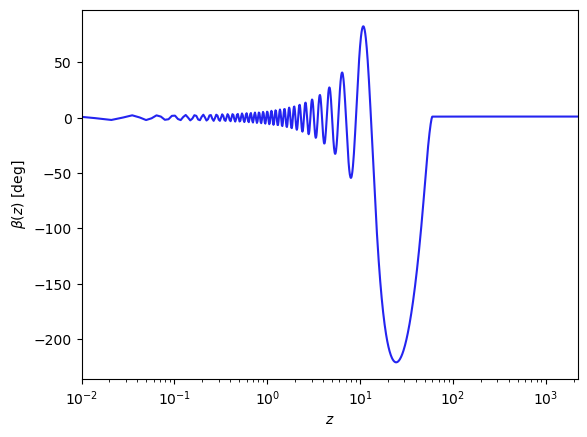

In [217]:
print(solphi0[-1])
xscale('log')
xlim(0.01,2.2e3)
xlabel(r'$z$')
#ylim(-90,90)
ylabel(r'$\beta(z)$ [deg]')
plot(z[::-1], phi.y[0][::-1])

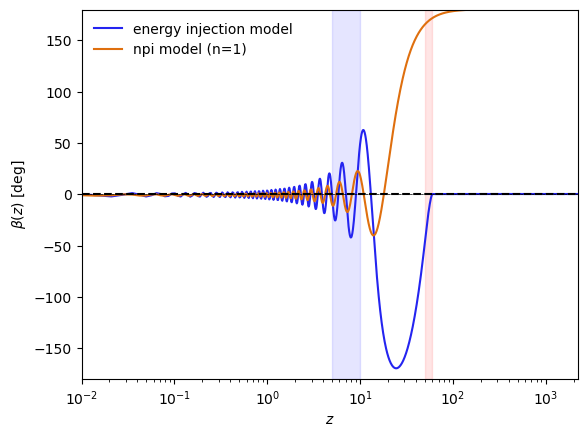

In [218]:
beta0 = 0.3
xscale('log')
xlim(0.01,2.2e3)
xlabel(r'$z$')
ylim(-180,180)
ylabel(r'$\beta(z)$ [deg]')
#plot(z[::-1], phi.y[0][::-1]*beta0,label='energy injection model')
plot(z[::-1], phi_inject[::-1]*beta0,label='energy injection model')
#plot(z[::-1], phi_normal.y[0][::-1]*180*1,label='npi model (n=1)')
plot(z[::-1], phi_normal[::-1]*(180*1+beta0),label='npi model (n=1)')
axvspan(5, 10, alpha=0.1, color='blue')
axvspan(z_end, z_start, alpha=0.1, color='red')
axhline(beta0,color='k',ls='--')
axhline(0,color='k',ls='--',lw=0.5)
legend()